# Exploratory Data Analysis

Notebook ini berisi proses exploratory data analysis (EDA) untuk memahami pola pergerakan harga emas, melakukan data cleaning, dan menyiapkan dataset sebelum digunakan pada tahap machine learning.

# 1. Import Library

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

sns.set_style('whitegrid')

# 2. Load Dataset

In [3]:
df = pd.read_csv('profin_raw.csv')

In [4]:
df.head()

,timestamp,adj_close,close,high,low,open,volume
0,NaN,GC=F,GC=F,GC=F,GC=F,GC=F,GC=F
1,2003-01-02,346.1000061035156,346.1000061035156,346.1000061035156,346.1000061035156,346.1000061035156,3
2,2003-01-03,351.20001220703125,351.20001220703125,351.20001220703125,345.20001220703125,345.20001220703125,0
3,2003-01-06,351.70001220703125,351.70001220703125,351.70001220703125,351.1000061035156,351.70001220703125,2
4,2003-01-07,347.29998779296875,347.29998779296875,349.29998779296875,347.29998779296875,349.29998779296875,4


# 3. Data Cleaning

In [5]:
df_clean = df.copy()

In [6]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5862 entries, 0 to 5861
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   timestamp  5861 non-null   object
 1   adj_close  5862 non-null   object
 2   close      5862 non-null   object
 3   high       5862 non-null   object
 4   low        5862 non-null   object
 5   open       5862 non-null   object
 6   volume     5862 non-null   object
dtypes: object(7)
memory usage: 320.7+ KB


### Menghapus Baris yang Tidak Valid

In [7]:
df_clean = df_clean.dropna(subset=['timestamp'])

### Mengubah Tipe Data Timestamp

In [8]:
df_clean['timestamp'] = pd.to_datetime(df_clean['timestamp'])

### Mengubah Nama Kolom Timestamp Menjadi Date

In [9]:
df_clean.rename(columns={'timestamp': 'date'}, inplace=True)

### Menjadikan Kolom Date Sebagai Index

In [10]:
df_clean.set_index('date', inplace=True)

### Menghapus Kolom yang Tidak Digunakan

In [11]:
df_clean.drop(columns=['adj_close'], inplace=True)

Kolom adj_close dihapus karena memiliki informasi yang serupa dengan close sehingga tidak digunakan pada analisis.

### Mengubah Kolom Menjadi Numerik

In [12]:
numeric_cols = ['close', 'high', 'low', 'open', 'volume']

for col in numeric_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

### Mengecek Missing Values

In [13]:
df_clean.isnull().sum()

close     0
high      0
low       0
open      0
volume    0
dtype: int64

### Mengecek Duplicate Data

In [14]:
df_clean.duplicated().sum()

8

In [15]:
df_clean = df_clean.drop_duplicates()

### Saving data

In [ ]:
df_clean.to_csv('profin_clean.csv')

# 4. Exploratory Data Analysis(EDA)

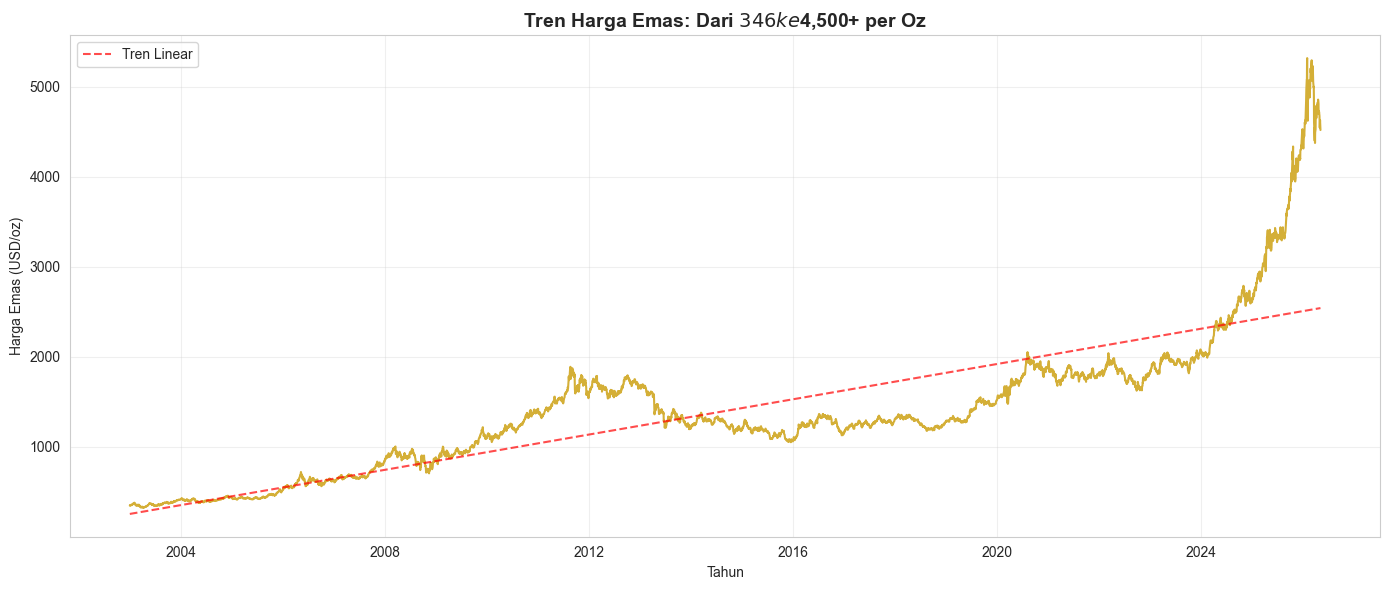

In [20]:
# Visualisasi 1: Tren Jangka Panjang (2003-2026)
plt.figure(figsize=(14, 6))
plt.plot(df_clean.index, df_clean['close'], linewidth=1.5, color='#D4AF37')
plt.title('Tren Harga Emas: Dari $346 ke $4,500+ per Oz', fontsize=14, fontweight='bold')
plt.xlabel('Tahun')
plt.ylabel('Harga Emas (USD/oz)')
plt.grid(True, alpha=0.3)

# Tambahkan garis tren sederhana
z = np.polyfit(mdates.date2num(df_clean.index), df_clean['close'], 1)
p = np.poly1d(z)
plt.plot(df_clean.index, p(mdates.date2num(df_clean.index)), 
         "r--", alpha=0.7, label='Tren Linear')
plt.legend()
plt.tight_layout()
plt.show()

Harga emas menunjukkan kenaikan yang sangat konsisten selama 20+ tahun terakhir, dari sekitar $346 per Oz di tahun 2004 menjadi lebih dari $4,500 di tahun 2026. Ini membuktikan bahwa emas adalah instrumen investasi yang handal untuk menjaga nilai kekayaan dalam jangka panjang.

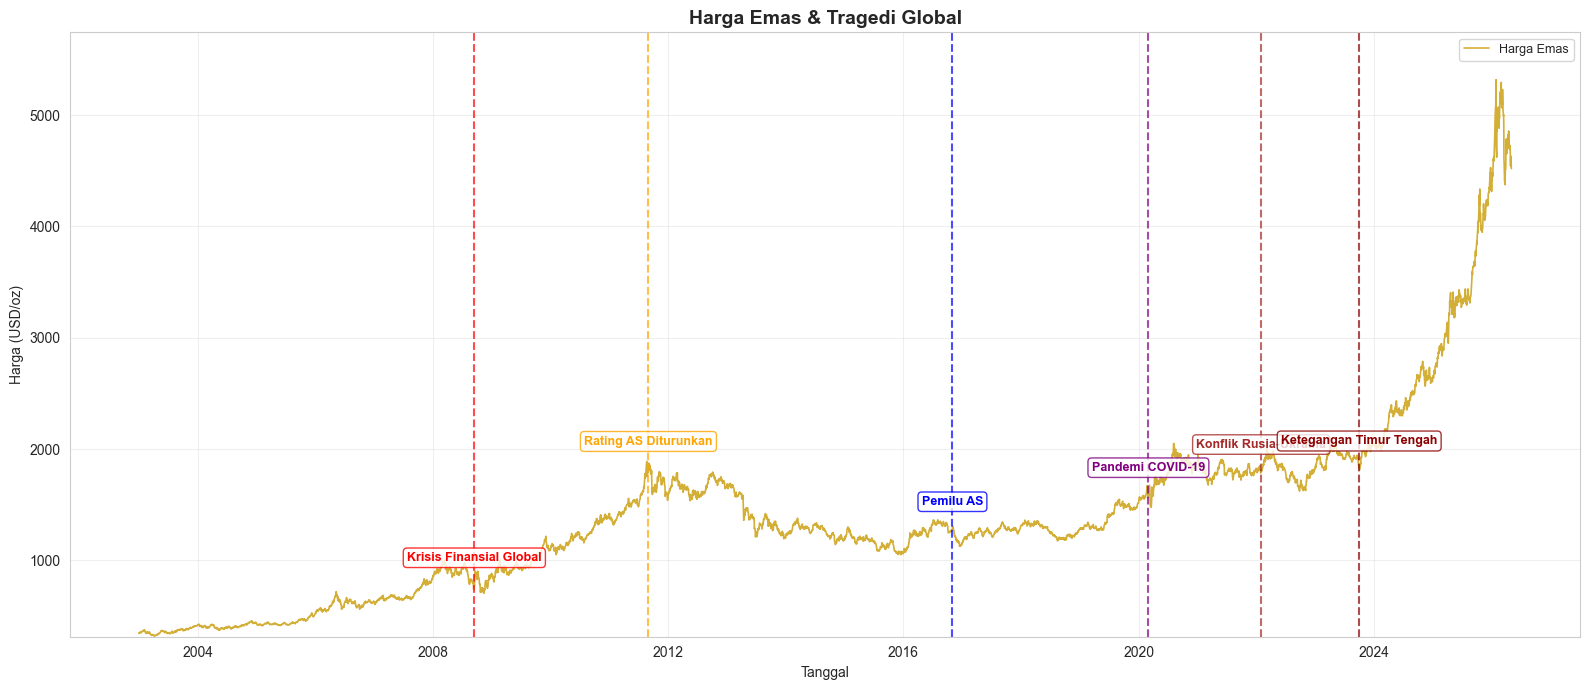

In [34]:
# 1. Pastikan index bertipe datetime & terurut
df_clean.index = pd.to_datetime(df_clean.index)
df_clean = df_clean.sort_index()

fig, ax = plt.subplots(figsize=(16, 7))
ax.plot(df_clean.index, df_clean['close'], linewidth=1.2, label='Harga Emas', color='#D4AF37', zorder=1)

events = [
    ('2008-09-15', 'Krisis Finansial Global', 'red'),
    ('2011-09-01', 'Rating AS Diturunkan', 'orange'),
    ('2016-11-01', 'Pemilu AS', 'blue'),
    ('2020-03-01', 'Pandemi COVID-19', 'purple'),
    ('2022-02-01', 'Konflik Rusia-Ukraina', 'brown'),
    ('2023-10-01', 'Ketegangan Timur Tengah', 'darkred')
]

# Siapkan ruang di atas grafik agar teks tidak terpotong
y_max = df_clean['close'].max()
ax.set_ylim(df_clean['close'].min() * 0.98, y_max * 1.08)

for date_str, label, color in events:
    try:
        event_date = pd.Timestamp(date_str)
        
        # Cari tanggal terdekat jika event jatuh di hari libur/tutup pasar
        if event_date not in df_clean.index:
            idx = df_clean.index.get_indexer([event_date], method='nearest')[0]
            plot_date = df_clean.index[idx]
        else:
            plot_date = event_date
            
        price = df_clean.loc[plot_date, 'close']
        
        # Garis vertikal (lebih jelas & di atas plot harga)
        ax.axvline(x=plot_date, color=color, linestyle='--', linewidth=1.5, alpha=0.7, zorder=2)
        
        # Teks dengan background box agar selalu terbaca
        ax.annotate(label, xy=(plot_date, price),
                    xytext=(0, 15), textcoords='offset points',
                    ha='center', va='bottom', fontsize=9, fontweight='bold', color=color,
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor=color, linewidth=1),
                    zorder=3)
                    
    except Exception as e:
        print(f"Event gagal diproses [{date_str}]: {e}")

ax.set_title('Harga Emas & Tragedi Global', fontsize=14, fontweight='bold')
ax.set_xlabel('Tanggal')
ax.set_ylabel('Harga (USD/oz)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Terlihat jelas bahwa setiap kali terjadi krisis atau ketidakpastian global (ditandai garis vertikal), harga emas cenderung melonjak. Emas benar-benar bersinar sebagai "safe haven" atau pelindung nilai saat dunia mengalami gejolak ekonomi, pandemi, atau ketegangan geopolitik.

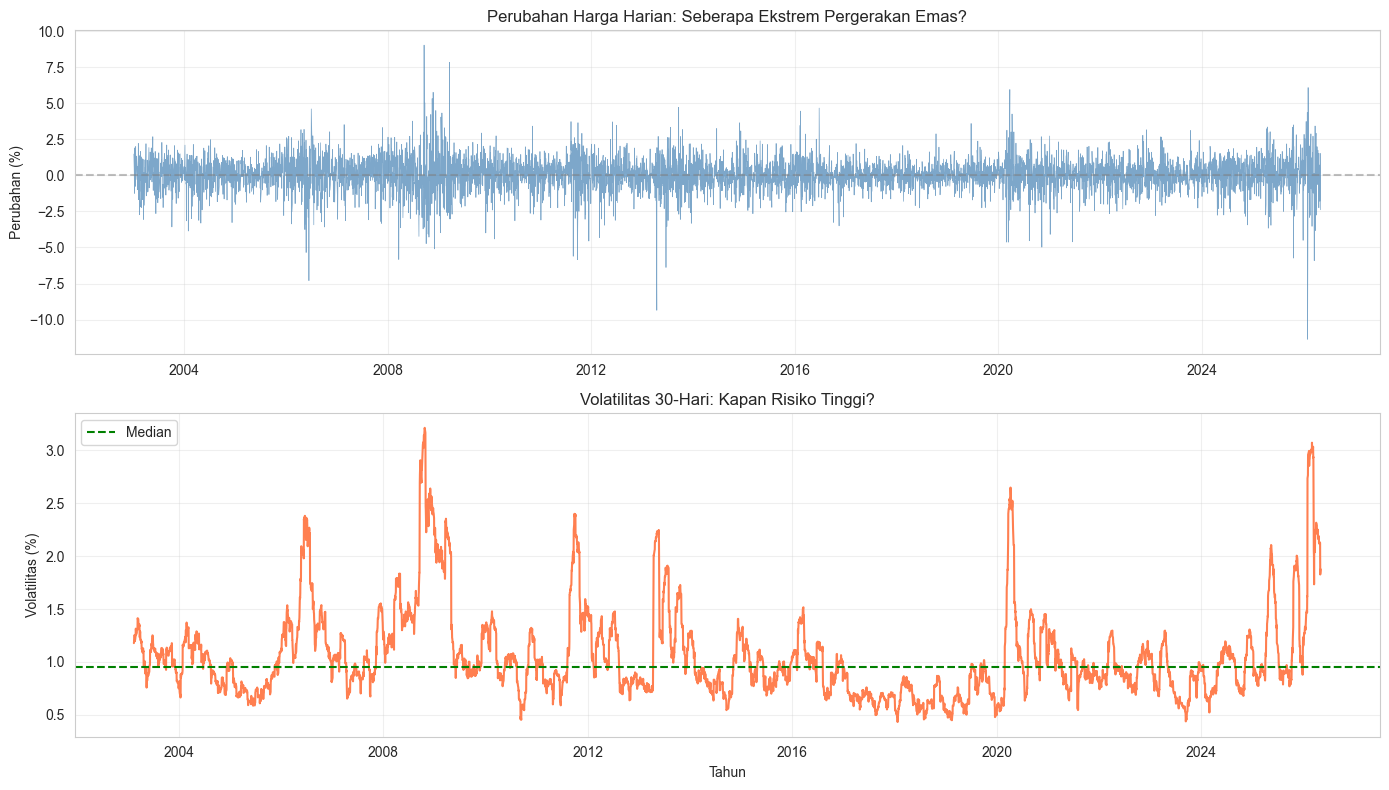

In [22]:
# Visualisasi 3: Volatilitas Harian (Persentase Perubahan)
df_clean['Daily_Return'] = df_clean['close'].pct_change() * 100
df_clean['Volatility_30D'] = df_clean['Daily_Return'].rolling(window=30).std()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Plot 1: Perubahan harga harian
axes[0].plot(df_clean.index, df_clean['Daily_Return'], color='steelblue', linewidth=0.5, alpha=0.7)
axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[0].set_title('Perubahan Harga Harian: Seberapa Ekstrem Pergerakan Emas?')
axes[0].set_ylabel('Perubahan (%)')
axes[0].grid(True, alpha=0.3)

# Plot 2: Volatilitas 30-hari rolling
axes[1].plot(df_clean.index, df_clean['Volatility_30D'], color='coral', linewidth=1.5)
axes[1].axhline(y=df_clean['Volatility_30D'].median(), color='green', linestyle='--', label='Median')
axes[1].set_title('Volatilitas 30-Hari: Kapan Risiko Tinggi?')
axes[1].set_ylabel('Volatilitas (%)')
axes[1].set_xlabel('Tahun')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Pergerakan harga emas sehari-hari relatif dengan volatilitas tinggi. Namun, ada periode-periode tertentu (terutama sekitar 2008 dan 2020) di mana volatilitas meningkat tajam, yang biasanya bertepatan dengan krisis ekonomi global.

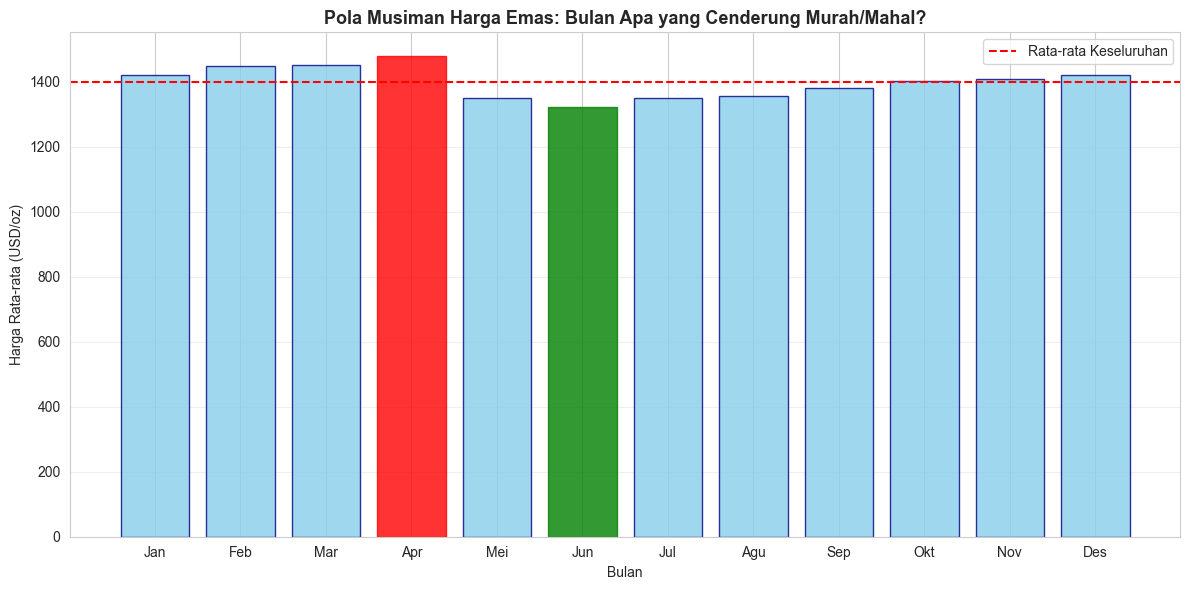


 Ringkasan Pola Musiman:
    Bulan termurah (rata-rata): Jun
    Bulan termahal (rata-rata): Apr
    Catatan: Ini pola historis, bukan jaminan masa depan!


In [35]:
# Visualisasi 4: Rata-rata Harga per Bulan (Pola Musiman)
df_clean['Month'] = df_clean.index.month
monthly_stats = df_clean.groupby('Month')['close'].agg(['mean', 'std']).reset_index()

months = ['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des']

plt.figure(figsize=(12, 6))
bars = plt.bar(months, monthly_stats['mean'], color='skyblue', edgecolor='navy', alpha=0.8)
plt.axhline(y=monthly_stats['mean'].mean(), color='red', linestyle='--', label='Rata-rata Keseluruhan')

# Highlight bulan terbaik & terburuk
best_month = monthly_stats['mean'].idxmax()
worst_month = monthly_stats['mean'].idxmin()
bars[best_month].set_color('red')
bars[worst_month].set_color('green')

plt.title('Pola Musiman Harga Emas: Bulan Apa yang Cenderung Murah/Mahal?', fontsize=13, fontweight='bold')
plt.xlabel('Bulan')
plt.ylabel('Harga Rata-rata (USD/oz)')
plt.legend()
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Tampilkan statistik sederhana
print(f"\n Ringkasan Pola Musiman:")
print(f"    Bulan termurah (rata-rata): {months[worst_month]}")
print(f"    Bulan termahal (rata-rata): {months[best_month]}")
print(f"    Catatan: Ini pola historis, bukan jaminan masa depan!")

C:\Users\HP\AppData\Local\Temp\ipykernel_27736\4027928872.py:61: UserWarning: Glyph 128285 (\N{TOP WITH UPWARDS ARROW ABOVE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_27736\4027928872.py:61: UserWarning: Glyph 128315 (\N{DOWN-POINTING RED TRIANGLE}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\HP\anaconda3\envs\h8_env\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 128285 (\N{TOP WITH UPWARDS ARROW ABOVE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\HP\anaconda3\envs\h8_env\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 128315 (\N{DOWN-POINTING RED TRIANGLE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


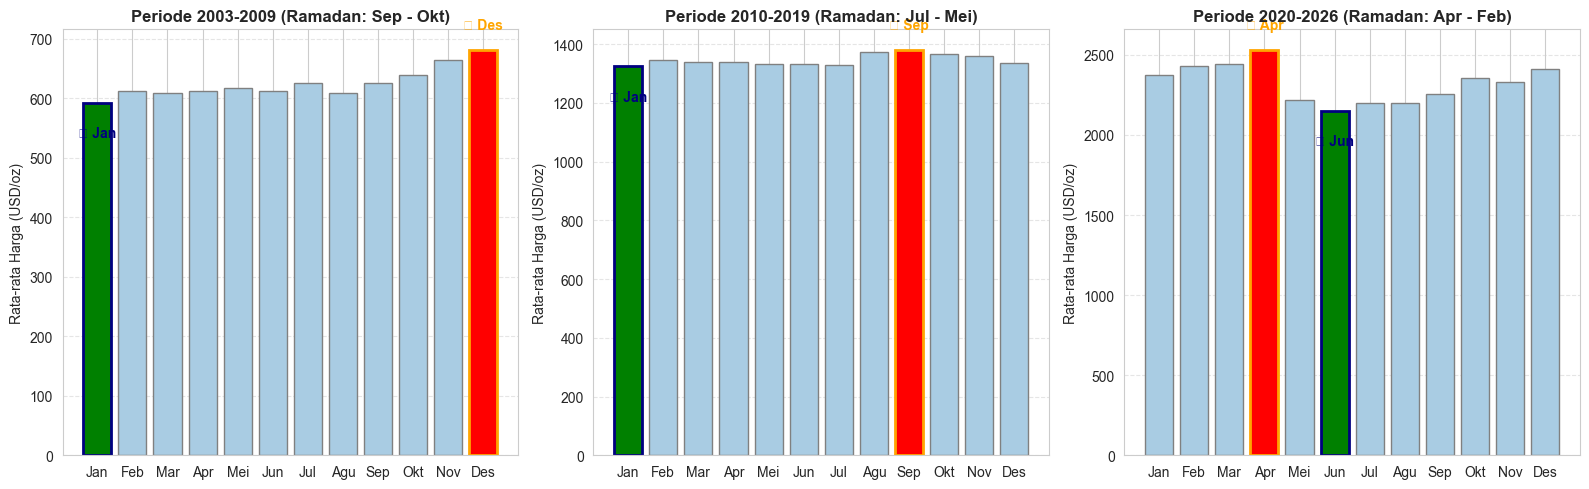

In [36]:
# 1. Definisikan Periode
# Kita slice dataframe berdasarkan tahun
period_1 = df_clean['2003':'2009']
period_2 = df_clean['2010':'2019']
period_3 = df_clean['2020':'2026'] # Data sampai 2026 mungkin belum penuh satu tahun, tergantung data Anda

periods = {
    "2003-2009 (Ramadan: Sep - Okt)": period_1,
    "2010-2019 (Ramadan: Jul - Mei)": period_2,
    "2020-2026 (Ramadan: Apr - Feb)": period_3
}

# 2. Setup Visualisasi
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'Mei', 'Jun', 'Jul', 'Agu', 'Sep', 'Okt', 'Nov', 'Des']

colors = {'high': 'red', 'low': 'green', 'avg': '#A9CCE3'}

for i, (title, data) in enumerate(periods.items()):
    # Hitung rata-rata harga per bulan
    # groupby(data.index.month) akan mengelompokkan 1-12
    monthly_avg = data.groupby(data.index.month)['close'].mean()
    
    ax = axes[i]
    
    # Plot Bar
    bars = ax.bar(range(1, 13), monthly_avg.values, color=colors['avg'], edgecolor='gray')
    
    # Highlight Bulan Termahal dan Termurah
    peak_month = monthly_avg.idxmax()
    low_month = monthly_avg.idxmin()
    
    # Ganti warna bar termahal
    bars[peak_month-1].set_color(colors['high'])
    bars[peak_month-1].set_edgecolor('orange')
    bars[peak_month-1].set_linewidth(2)
    
    # Ganti warna bar termurah
    bars[low_month-1].set_color(colors['low'])
    bars[low_month-1].set_edgecolor('navy')
    bars[low_month-1].set_linewidth(2)
    
    # Formatting Chart
    ax.set_title(f"Periode {title}", fontsize=12, fontweight='bold')
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(month_names)
    ax.set_ylabel("Rata-rata Harga (USD/oz)")
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    
    # Tambahkan teks anotasi sederhana
    ax.annotate(f'🔝 {month_names[peak_month-1]}', 
                xy=(peak_month, monthly_avg[peak_month]), 
                xytext=(0, 15), textcoords='offset points', 
                ha='center', fontsize=10, color='orange', fontweight='bold')
    
    ax.annotate(f'🔻 {month_names[low_month-1]}', 
                xy=(low_month, monthly_avg[low_month]), 
                xytext=(0, -25), textcoords='offset points', 
                ha='center', fontsize=10, color='navy', fontweight='bold')

plt.tight_layout()
plt.show()

Terdapat pola musiman yang menarik: April cenderung menjadi bulan dengan harga emas termurah, sementara Juni menjadi bulan dengan harga termahal. Ini bisa menjadi pertimbangan timing untuk pembelian emas.

 - 2003–2019: Distribusi harga per bulan relatif datar. Bulan Ramadan tidak menunjukkan penyimpangan harga yang signifikan.
-  2020–2026: Pola jelas terbentuk. Harga cenderung mencapai puncak di Maret, terkoreksi di April (bulan puasa), dan rebound di Mei.

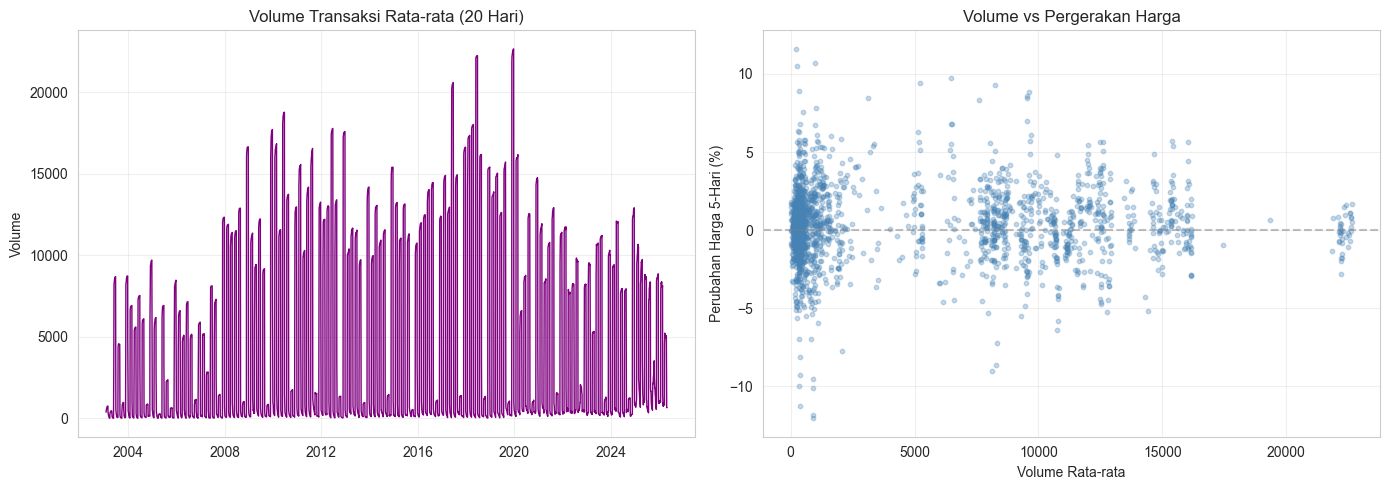


Korelasi Volume vs Perubahan Harga: 0.016
   (Nilai mendekati 0 = hubungan lemah, ±1 = hubungan kuat)


In [38]:
# Visualisasi 5: Volume vs Perubahan Harga
df_clean['Volume_MA20'] = df_clean['volume'].rolling(window=20).mean()
df_clean['Price_Change_5D'] = df_clean['close'].pct_change(5) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Volume over time
axes[0].plot(df_clean.index, df_clean['Volume_MA20'], color='purple', linewidth=1)
axes[0].set_title('Volume Transaksi Rata-rata (20 Hari)')
axes[0].set_ylabel('Volume')
axes[0].grid(True, alpha=0.3)

# Plot 2: Scatter volume vs price change (sample untuk kejelasan)
sample = df_clean.dropna(subset=['Volume_MA20', 'Price_Change_5D']).tail(2000)
axes[1].scatter(sample['Volume_MA20'], sample['Price_Change_5D'], 
                alpha=0.3, s=10, color='steelblue')
axes[1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Volume Rata-rata')
axes[1].set_ylabel('Perubahan Harga 5-Hari (%)')
axes[1].set_title('Volume vs Pergerakan Harga')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Hitung korelasi sederhana
corr = sample['Volume_MA20'].corr(sample['Price_Change_5D'])
print(f"\nKorelasi Volume vs Perubahan Harga: {corr:.3f}")
print("   (Nilai mendekati 0 = hubungan lemah, ±1 = hubungan kuat)")

Volume transaksi emas menunjukkan fluktuasi yang signifikan dari waktu ke waktu. Terlihat ada korelasi yang lemah antara volume dan pergerakan harga, yang berarti volume tinggi tidak selalu menghasilkan pergerakan harga yang besar.

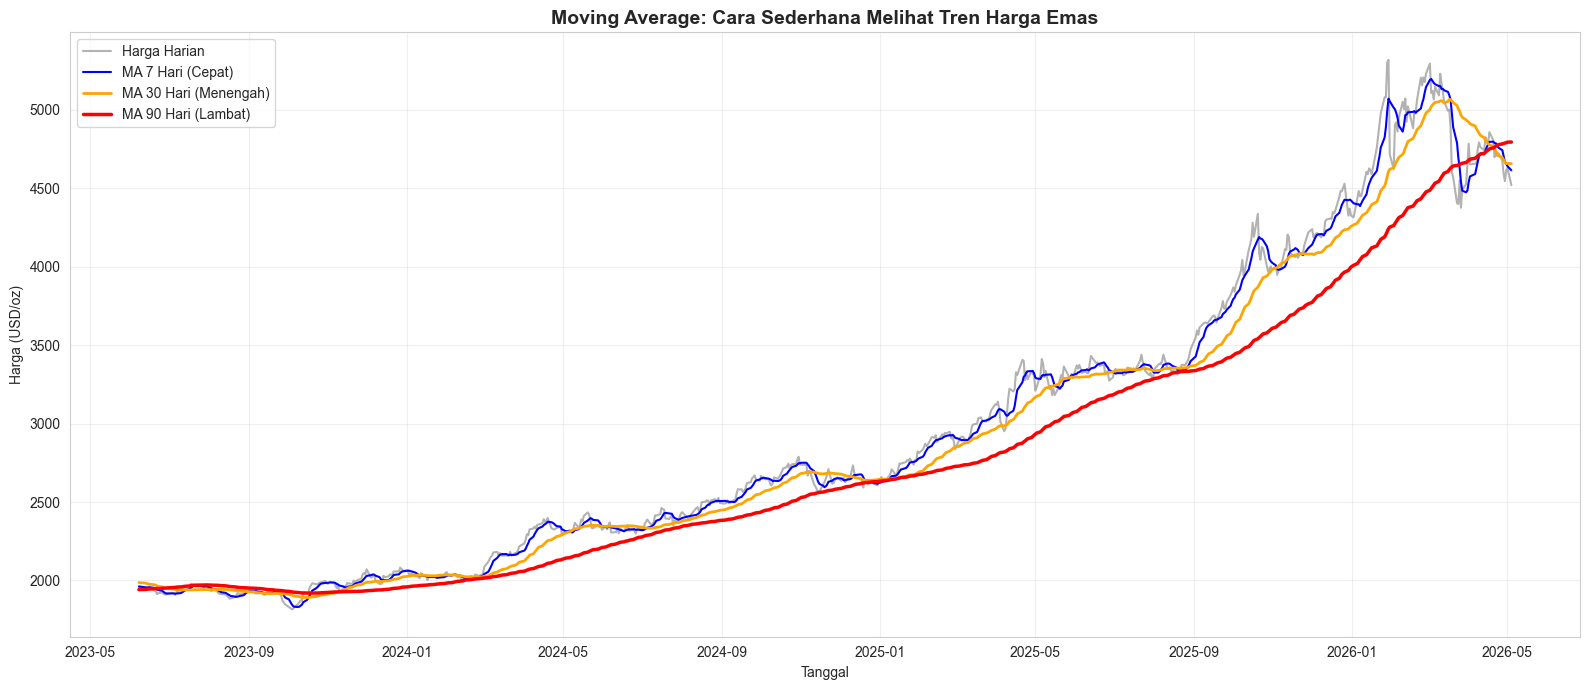


Status Terkini (2026-05-04):
   Harga Emas: $4519.50/oz
   MA 7 Hari : $4614.07
   MA 30 Hari: $4656.60
   MA 90 Hari: $4794.27
   Sinyal: BEARISH (Tren Turun - Hati-hati)


In [39]:
# Visualisasi 6: Harga + Moving Average (Sinyal Sederhana)
df_clean['MA7'] = df_clean['close'].rolling(window=7).mean()   # Jangka pendek
df_clean['MA30'] = df_clean['close'].rolling(window=30).mean() # Jangka menengah
df_clean['MA90'] = df_clean['close'].rolling(window=90).mean() # Jangka panjang

# Tampilkan 2 tahun terakhir agar tidak terlalu padat
recent = df_clean.tail(730)  # ~2 tahun

plt.figure(figsize=(16, 7))
plt.plot(recent.index, recent['close'], alpha=0.6, label='Harga Harian', color='gray')
plt.plot(recent.index, recent['MA7'], label='MA 7 Hari (Cepat)', color='blue', linewidth=1.5)
plt.plot(recent.index, recent['MA30'], label='MA 30 Hari (Menengah)', color='orange', linewidth=2)
plt.plot(recent.index, recent['MA90'], label='MA 90 Hari (Lambat)', color='red', linewidth=2.5)

plt.title('Moving Average: Cara Sederhana Melihat Tren Harga Emas', fontsize=14, fontweight='bold')
plt.xlabel('Tanggal')
plt.ylabel('Harga (USD/oz)')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Tampilkan sinyal terbaru
latest = recent.iloc[-1]
print(f"\nStatus Terkini ({recent.index[-1].date()}):")
print(f"   Harga Emas: ${latest['close']:.2f}/oz")
print(f"   MA 7 Hari : ${latest['MA7']:.2f}")
print(f"   MA 30 Hari: ${latest['MA30']:.2f}")
print(f"   MA 90 Hari: ${latest['MA90']:.2f}")

if latest['MA7'] > latest['MA30'] > latest['MA90']:
    print(f"   Sinyal: BULLISH (Tren Naik - Potensi Beli)")
elif latest['MA7'] < latest['MA30'] < latest['MA90']:
    print(f"   Sinyal: BEARISH (Tren Turun - Hati-hati)")
else:
    print(f"   Sinyal: SIDEWAYS (Tren Tidak Jelas - Tunggu Konfirmasi)")

Dengan menggunakan rata-rata pergerakan 7, 30, dan 90 hari, saat ini (Mei 2026) emas menunjukkan sinyal BEARISH atau tren turun jangka pendek. Harga saat ini $4,519 berada di bawah rata-rata 7 hari ($4,614), mengindikasikan perlu kehati-hatian bagi trader jangka pendek.

# 5. Kesimpulan

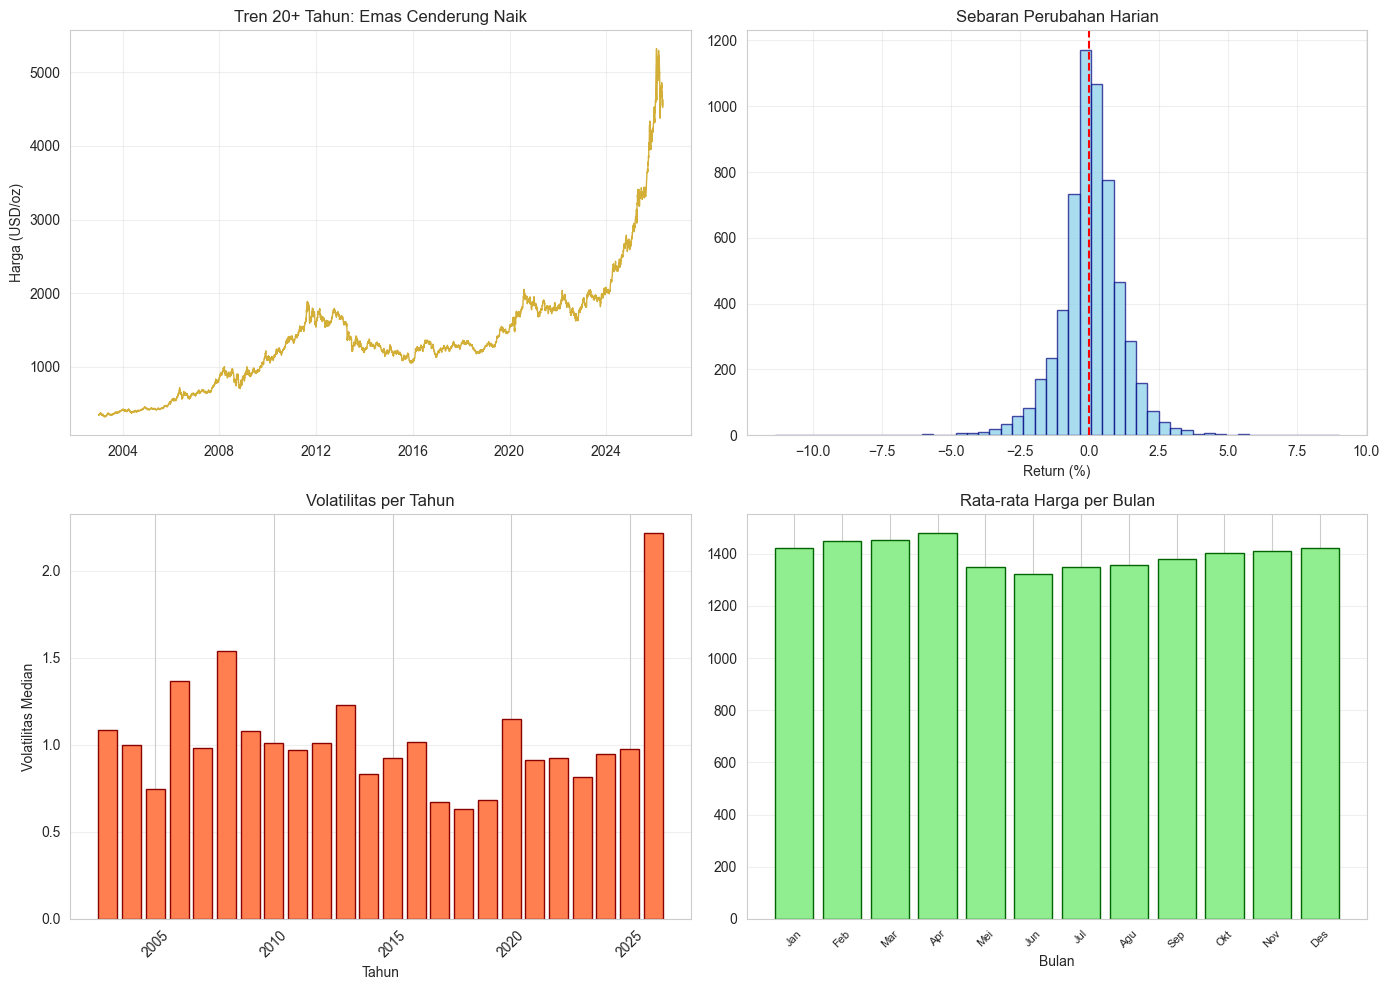

In [40]:
# Visualisasi Summary Dashboard
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Tren Jangka Panjang
axes[0,0].plot(df_clean.index, df_clean['close'], color='#D4AF37', linewidth=1)
axes[0,0].set_title('Tren 20+ Tahun: Emas Cenderung Naik')
axes[0,0].set_ylabel('Harga (USD/oz)')
axes[0,0].grid(True, alpha=0.3)

# 2. Distribusi Return
returns = df_clean['Daily_Return'].dropna()
axes[0,1].hist(returns, bins=50, color='skyblue', edgecolor='navy', alpha=0.7)
axes[0,1].axvline(x=0, color='red', linestyle='--')
axes[0,1].set_title('Sebaran Perubahan Harian')
axes[0,1].set_xlabel('Return (%)')
axes[0,1].grid(True, alpha=0.3)

# 3. Volatilitas per Tahun
df_clean['Year'] = df_clean.index.year
yearly_vol = df_clean.groupby('Year')['Volatility_30D'].median()
axes[1,0].bar(yearly_vol.index, yearly_vol.values, color='coral', edgecolor='darkred')
axes[1,0].set_title('Volatilitas per Tahun')
axes[1,0].set_xlabel('Tahun')
axes[1,0].set_ylabel('Volatilitas Median')
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].grid(axis='y', alpha=0.3)

# 4. Pola Musiman
monthly_avg = df_clean.groupby('Month')['close'].mean()
axes[1,1].bar(range(1,13), monthly_avg.values, color='lightgreen', edgecolor='darkgreen')
axes[1,1].set_title('Rata-rata Harga per Bulan')
axes[1,1].set_xlabel('Bulan')
axes[1,1].set_xticks(range(1,13))
axes[1,1].set_xticklabels(['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des'], rotation=45, fontsize=8)
axes[1,1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Proses Exploratory Data Analysis (EDA) ini dilakukan untuk memahami pola pergerakan harga emas dan menyiapkan dataset sebelum digunakan pada tahap machine learning. Dataset yang digunakan berisi data historis harga emas dengan kolom timestamp, adj_close, close, high, low, open, dan volume yang mencakup periode dari Januari 2003 hingga Mei 2026. Tahap data cleaning dimulai dengan menghapus baris yang tidak valid, mengubah tipe data timestamp menjadi datetime, mengganti nama kolom timestamp menjadi date, dan menjadikannya sebagai index dataframe. Kolom adj_close dihapus karena memiliki informasi yang serupa dengan kolom close, sedangkan kolom numerik seperti close, high, low, open, dan volume dikonversi ke tipe data numerik untuk memastikan konsistensi analisis. Setelah proses cleaning, dataset akhir memiliki 5.853 baris data dengan 5 kolom fitur yang siap digunakan. Hasil eksplorasi menunjukkan bahwa harga emas mengalami tren kenaikan yang konsisten dari sekitar $346 per ons di tahun 2004 menjadi lebih dari $4.500 per ons di tahun 2026, yang membuktikan bahwa emas merupakan instrumen investasi yang handal untuk menjaga nilai kekayaan dalam jangka panjang. Analisis distribusi daily return menunjukkan bahwa pergerakan harga harian relatif dengan volatilitas tinggi, terutama pada periode krisis ekonomi global seperti tahun 2008 dan 2020. Korelasi antara volume transaksi dan perubahan harga tergolong lemah, yang berarti volume tinggi tidak selalu menghasilkan pergerakan harga yang besar. Dataset yang telah dibersihkan kemudian disimpan dalam format CSV dengan nama 'profin_clean.csv' untuk digunakan pada tahap selanjutnya.